# Phân tích dữ liệu (EDA) cho bài toán Dự đoán chi tiêu mua xe
Mục tiêu: Khám phá dữ liệu trên tập `train.csv` để tìm ra các đặc trưng quan trọng và phát hiện điểm bất thường trước khi đưa vào mô hình.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Tải dữ liệu
try:
    train_df = pd.read_csv('../data/preprocessed/train.csv')
    display(train_df.head())
except FileNotFoundError:
    print('Không tìm thấy file train.csv. Vui lòng kiểm tra lại đường dẫn!')

,gender,age,annual Salary,credit card debt,net worth,car purchase amount
0,0.0,0.325146,0.629180,0.488604,0.622060,0.523032
1,1.0,0.399740,0.451081,0.326061,0.206252,0.289008
2,0.0,0.781569,0.442103,0.661957,0.553572,0.645458
3,0.0,0.810585,0.485475,0.637629,0.611490,0.713029
4,0.0,0.226851,0.267024,0.535453,0.604695,0.228915


## 1. Kiểm tra tổng quan và dữ liệu khuyết thiếu

In [2]:
print("Thông tin tổng quan:")
train_df.info()

print("\nThống kê mô tả:")
display(train_df.describe())

print("\nSố lượng missing values ở mỗi cột:")
print(train_df.isnull().sum())

Thông tin tổng quan:
<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               400 non-null    float64
 1   age                  400 non-null    float64
 2   annual Salary        400 non-null    float64
 3   credit card debt     400 non-null    float64
 4   net worth            400 non-null    float64
 5   car purchase amount  400 non-null    float64
dtypes: float64(6)
memory usage: 18.9 KB

Thống kê mô tả:


,gender,age,annual Salary,credit card debt,net worth,car purchase amount
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,0.500000,0.524586,0.524764,0.476718,0.415839,0.492198
std,0.500626,0.162354,0.148791,0.175468,0.180612,0.152828
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.420485,0.429208,0.364433,0.280672,0.397679
50%,0.500000,0.516969,0.535505,0.479306,0.411473,0.491245
75%,1.000000,0.631526,0.627619,0.596822,0.548505,0.584173
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000



Số lượng missing values ở mỗi cột:
gender                 0
age                    0
annual Salary          0
credit card debt       0
net worth              0
car purchase amount    0
dtype: int64


## 2. Phân tích biến phân loại (Categorical) - Gender
Kiểm tra sự phân bố giới tính trong tập dữ liệu và mức chi tiêu trung bình theo giới tính.

/tmp/ipykernel_9345/1047262903.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x='gender', ax=axes[0], palette='Set2')
/tmp/ipykernel_9345/1047262903.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_df, x='gender', y='car purchase amount', ax=axes[1], palette='Set2')


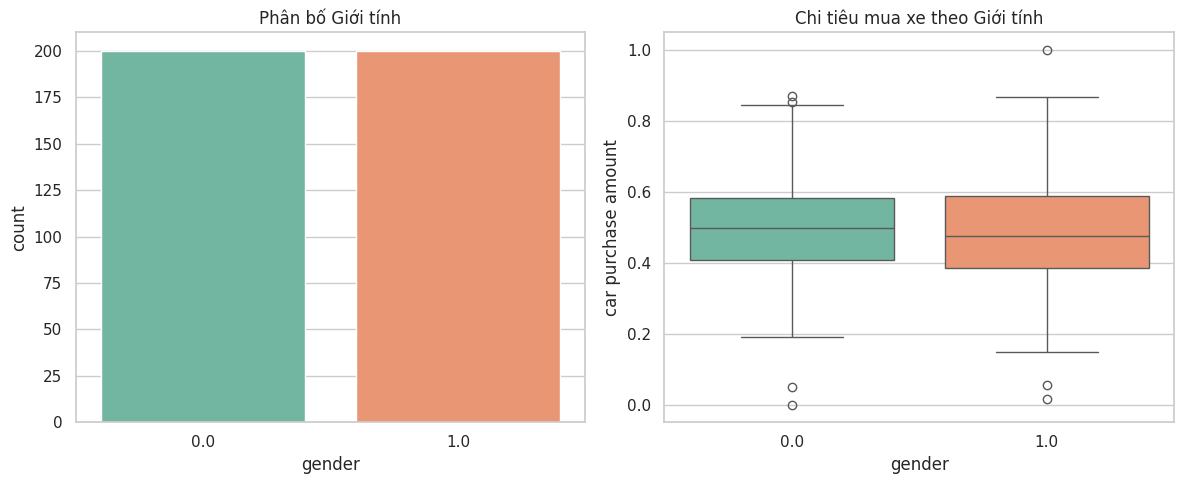

In [3]:
if 'gender' in train_df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Đếm số lượng nam/nữ
    sns.countplot(data=train_df, x='gender', ax=axes[0], palette='Set2')
    axes[0].set_title('Phân bố Giới tính')
    
    # So sánh chi tiêu trung bình giữa 2 giới tính
    sns.boxplot(data=train_df, x='gender', y='car purchase amount', ax=axes[1], palette='Set2')
    axes[1].set_title('Chi tiêu mua xe theo Giới tính')
    
    plt.tight_layout()
    plt.show()

## 3. Phân tích biến số học (Numerical Analysis)

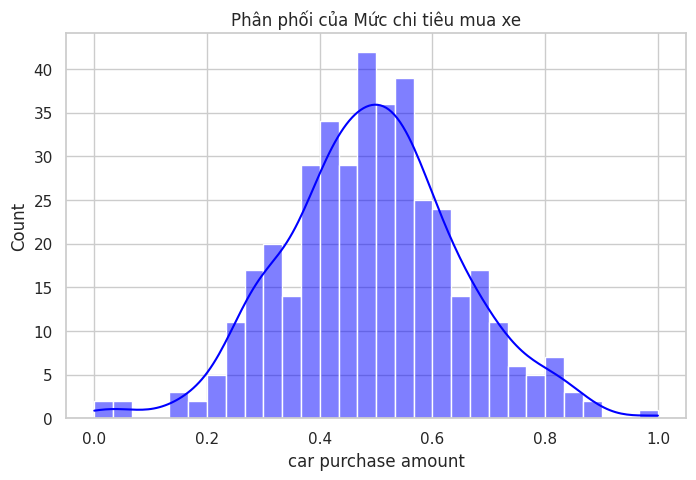

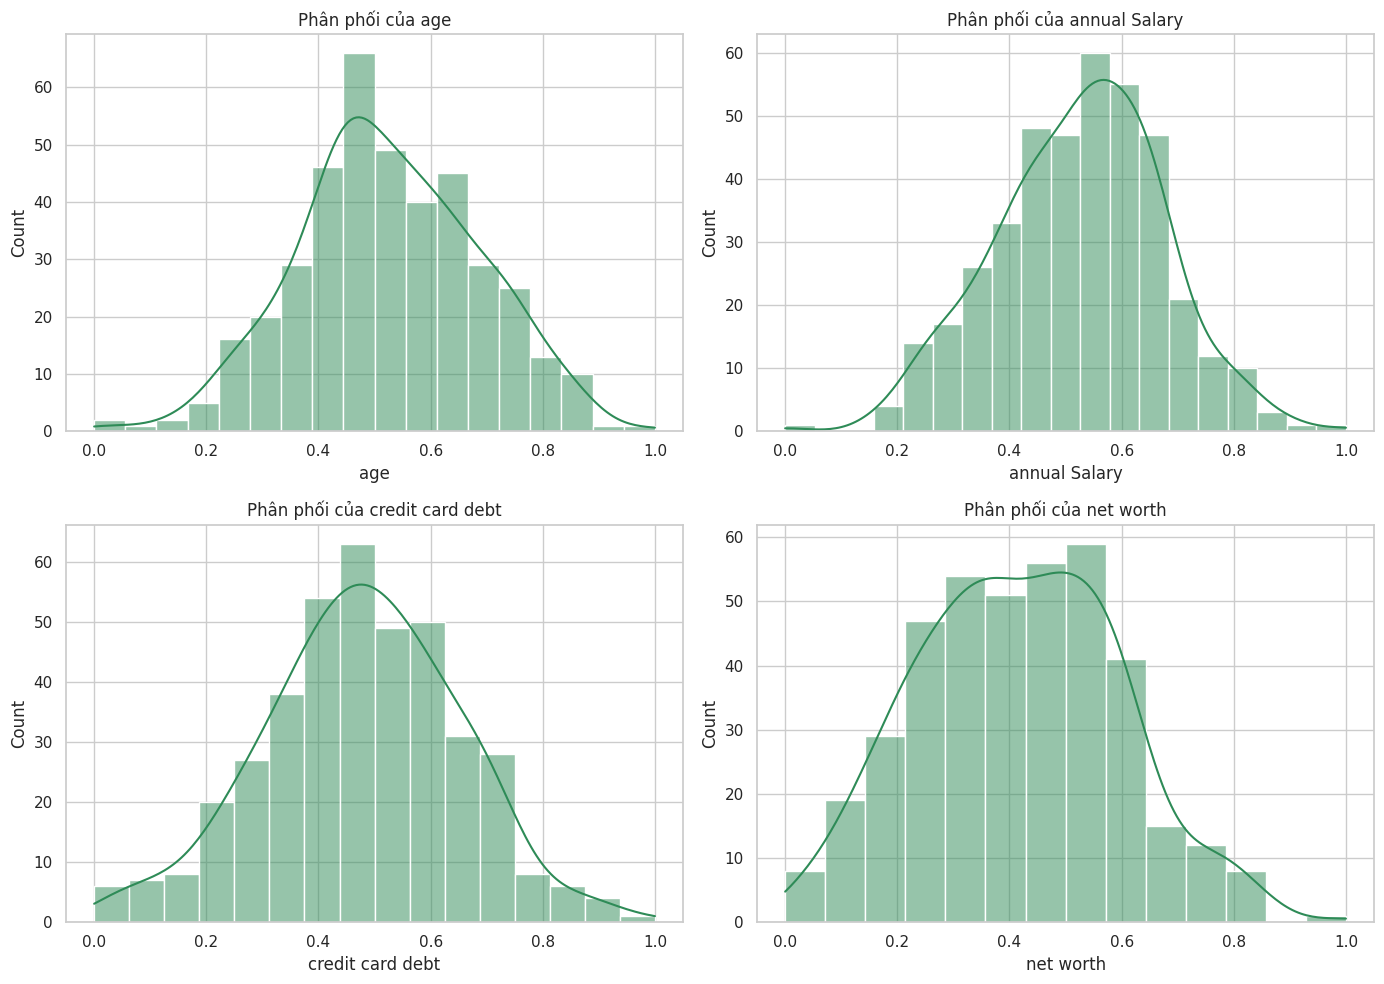

In [4]:
# Phân phối biến mục tiêu
plt.figure(figsize=(8, 5))
sns.histplot(train_df['car purchase amount'], kde=True, color='blue', bins=30)
plt.title('Phân phối của Mức chi tiêu mua xe')
plt.show()

# Phân phối các biến số học đầu vào
features = ['age', 'annual Salary', 'credit card debt', 'net worth']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(features):
    if col in train_df.columns:
        sns.histplot(train_df[col], kde=True, ax=axes[i], color='seagreen')
        axes[i].set_title(f'Phân phối của {col}')

plt.tight_layout()
plt.show()

## 4. Ma trận tương quan (Correlation Analysis)

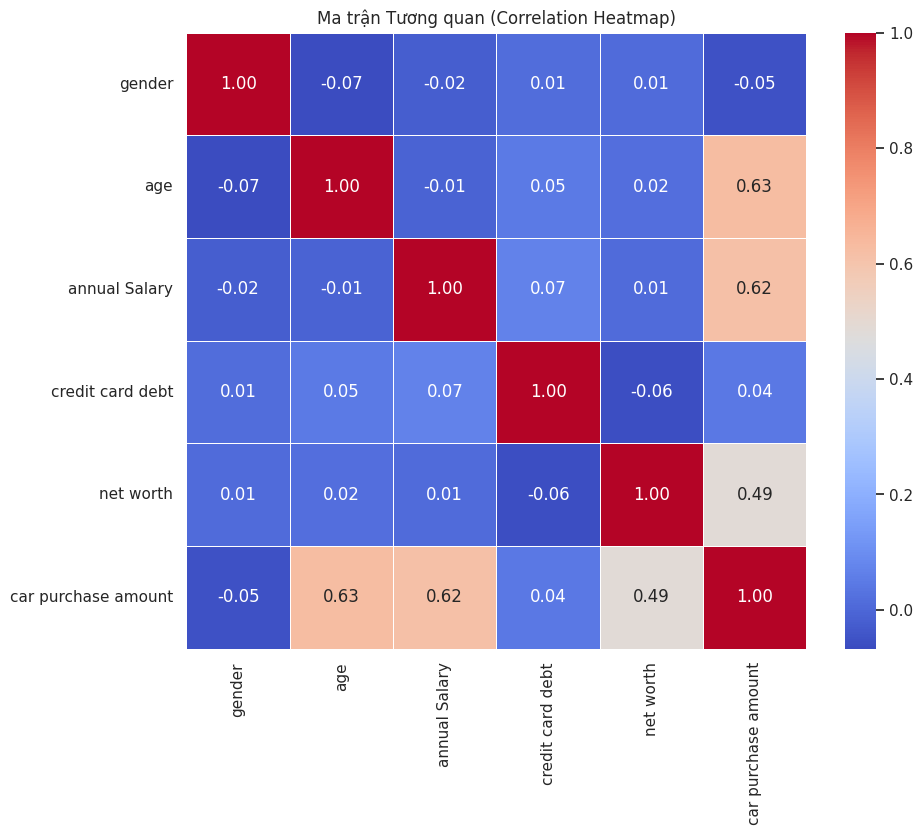

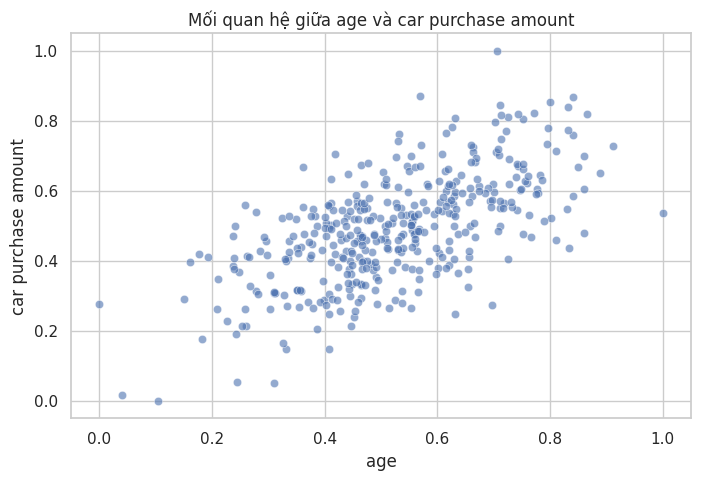

In [5]:
plt.figure(figsize=(10, 8))
# Bỏ qua các cột không phải dạng số (như text) khi tính tương quan
numeric_df = train_df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Ma trận Tương quan (Correlation Heatmap)')
plt.show()

# Scatter plot cho biến tương quan mạnh nhất
target_col = 'car purchase amount'
if len(numeric_df.columns) > 1 and target_col in numeric_df.columns:
    correlations = correlation_matrix[target_col].drop(target_col)
    top_feature = correlations.idxmax()
    
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=train_df, x=top_feature, y=target_col, alpha=0.6)
    plt.title(f'Mối quan hệ giữa {top_feature} và {target_col}')
    plt.show()